# QAOA for TSP with noise model



Libraries

In [3]:
# SDK install

%pip install mpqp --upgrade

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from mpqp.tools import Matrix
from mpqp.measures import I, Z, Y, X, PauliString

Cost Hamiltonian based on the TSP QUBO

## Preamble 

In the previous import, the functions "I, Z, Y, and X" are imported. **THESE ARE NOT QUANTUM GATES** but observables!!!

This is a distinction that is quite intuitive at first glance. Here, these mathematical objects are used to "encode" information into the Hamiltonian, but not directly to perform an operation (as you will see later, we will use an exponential to encode our quantum gates). In short, this is not fundamental for understanding this TP, but I had to tell you to be strictly rigorous. Moreover, in the upcoming version of MPQP (probably the next one), these observables will be denoted as 'pI, pX, pY, and pZ' to avoid confusion!

## The Variational Quantum Algorithm: QAOA (Quantum Approximate Optimization Algorithm)

#### Let's review the principle of the algorithm

The QAOA algorithm is a well-known member of the Variational Quantum Algorithm (VQA) class. Its successful operation requires 3 main ingredients:

* **A cost function**, encoding the optimization problem we want to solve, modeled by a Hamiltonian $H_C$.
* **An Ansatz** describing the architecture of the quantum circuit used to amplify the probabilities of optimal solutions, including our cost Hamiltonian $H_C$ and a "mixing" Hamiltonian $H_M$. As a reminder, Hamiltonians are found in the Schrödinger equation, and they are the same operators introduced when we talked about quantum annealing.
* **A classical optimizer** to search for the optimal parameters of our quantum circuit (very similar to the optimizers used in neural networks).

In this TP, we will develop our own QAOA using the MPQP quantum programming library developed by the startup ColibriTD. The idea is to solve a simple problem: Find the minimum of a function $C(x)$, defined as:

$$C(x) = 3x_0x_1 - 4x_0 - 2x_1 + 1$$

The first step is to define a Hamiltonian $H_C$. We seek to define it such that its ground state (minimum energy) corresponds to the minimum of the cost function. This function has two variables $x_0$ and $x_1$. Thus, we will use a two-qubit system $\ket{x}=\ket{x_0x_1}$ encoding a superposition of the four possible binary combinations.

Subsequently, we will use the following relationship to define our Hamiltonians from mathematical functions, such as our cost function:

$$ 
x_i = \frac{I^{\otimes n} - Z_i}{2} 
$$  
$$ 
\text{with } ~~ Z_i = \underbrace{I \otimes \cdots \otimes I}_{i} \otimes Z \otimes \underbrace{I \otimes \cdots \otimes I}_{n-i-1} 
$$

> **_IMPORTANT:_** **In the case of PauliString in MPQP**, the Kronecker product $\otimes$ is written as "@".
> 
> Do not confuse this with the matrix product in numpy, which for two matrices $A$ and $B$ is written the same way but performs $A \times B$ instead of $A \otimes B$ !!!
> Here, we will use @ exclusively within the context of PauliString.

**1) Write a Python function that returns the Hamiltonian $H_C$ associated with the cost function:**

In [2]:
def hamiltonian_cost() -> PauliString:
    #n = 2
    x0 = (I@I - Z@I)/2
    x1 = (I@I - I@Z)/2
    x0x1 = (I@I -Z@I-I@Z+Z@Z)/4
    return 3*x0x1 - 4*x0 - 2*x1 +1*(I@I) #on remplace x0*x0 par ce que ça vaut

We define the mixing Hamiltonian $H_M$ as a sum of local Pauli $X_i$ observables such that:
$$ 
H_M = \sum_{i=0}^{n-1} X_i 
$$ 
$$ 
\text{with } ~~ X_i = \underbrace{I \otimes \cdots \otimes I}_{i} \otimes X \otimes \underbrace{I \otimes \cdots \otimes I}_{n-i-1} 
$$

**2) Write a Python function that returns the Hamiltonian $H_M$ associated with the mixing operator:**

In [3]:
def hamiltonian_mixer() -> PauliString:
    X0 = X@I
    X1 = I@X
    return X0 + X1

Once these Hamiltonians are defined, we must create the evolution operator that will be repeated several times to amplify the probabilities of finding the lowest energy solutions, i.e., minimizing our cost function. Recall that the time evolution described by a time-independent Hamiltonian $H$ can be represented by a 1-parameter unitary operator $U(\gamma) = e^{-i\gamma H}$. This implies that we must calculate the exponential of a matrix, which is enabled by the `expm` function from the `scipy.linalg` library.

> **_Tip:_** The MPQP function `PauliString.to_matrix()` allows you to convert a Pauli string object into its associated matrix.

In [4]:
from scipy.linalg import expm

**3) Write a Python function that returns $U_{C}(\gamma)$ associated with the Hamiltonian $H_C$ and the parameter $\gamma$:**

In [10]:
def unitary_matrix_hamiltonian_cost(gamma: float) -> Matrix:
    
    return expm(-1j*gamma*hamiltonian_cost().to_matrix())

**4) Write a Python function that returns $U_{M}(\beta)$ associated with the Hamiltonian $H_M$ and the parameter $\beta$:**

In [11]:
def unitary_matrix_hamiltonian_mixer(beta: float) -> Matrix:
    
    return expm(-1j*beta*hamiltonian_mixer().to_matrix())

The next step is to construct the "parameterized" QAOA quantum circuit, which we will denote as $U$, and which depends on $2d$ parameters $\{\gamma_1, \beta_1, \dots, \gamma_d, \beta_d\}$, where $d$ is the "depth" of our Ansatz. Recall that the QAOA circuit is composed of an alternation of unitary operators encoding the system's evolution according to the Hamiltonians $H_C$ and $H_M$, with a parameter associated with each occurrence of each operator.

In other words, we have:
$$U(\gamma_1, \beta_1, \dots, \gamma_d, \beta_d) = e^{-i\beta_d H_M}e^{-i\gamma_d H_C} \cdots e^{-i\beta_1 H_M}e^{-i\gamma_1 H_C}$$

**5) Write a Python function that takes the Ansatz parameters as input and returns the QAOA circuit as output:**

> **_Tip:_** We must create "CustomGates", which are defined like our "gate objects" in previous Qiskit TPs. The language changes, but the logic remains strictly the same:
>+ These are objects that we must "append" to our circuit.
>+ Their first parameter is the unitary matrix defining the action of the quantum gate.
>+ The second argument is the list of "target" qubits, i.e., those to which they are applied (note that if a 1-qubit gate has several "targets", then the same gate will be applied to the entire target list).

In [41]:
from typing import Optional

from mpqp.core.circuit import QCircuit
from mpqp.gates import Gate, CustomGate, UnitaryMatrix

def construct_qaoa_ansatz(parameters: list[float], depth: Optional[int]=None):
    if depth is None:
        if len(parameters) % 2 != 0:
            raise ValueError("parameters length must be even (2*depth).")
        depth = len(parameters) // 2

    if len(parameters) != 2 * depth:
        raise ValueError("Wrong parameters length vs depth.")

    gates: list[Gate] = []
     
    for d in range(depth):
        gamma = parameters[2 * d]
        beta  = parameters[2 * d + 1]

        # Rajouter à partir d'ici les portas quantiques paramétrées
        
        gates.append(CustomGate(unitary_matrix_hamiltonian_cost(gamma), [0,1]))
        gates.append(CustomGate(unitary_matrix_hamiltonian_mixer(beta), [0,1]))
    
    return QCircuit(gates)

Let's display the circuit with some dummy parameters to check that it works correctly...

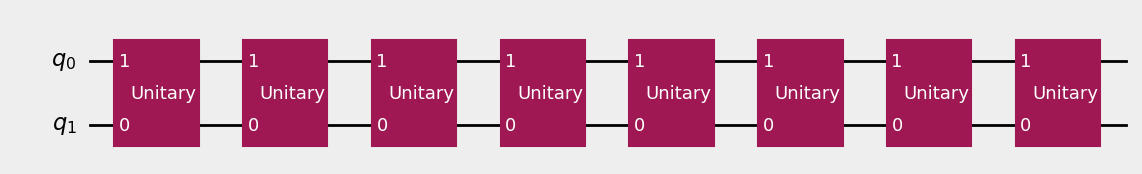

In [16]:
construct_qaoa_ansatz([1,2,3,4,5,6,7,8]).display(warn=False)

Now that we have the structure of our circuit to optimize, we focus on an important element of our algorithm: calculating the loss function to be optimized. Here, we want to minimize the cost function $C(x)$, which is equivalent to finding the ground state $\ket{\psi}$ of the cost Hamiltonian $H_C$, which can be expressed as:

$$\ket{\psi} = \text{arg } \min_{\ket{x}} \ \langle x \mid H_C \mid x \rangle$$

Thus, at each iteration of the algorithm, we will evaluate the expectation value of $H_C$ relative to the state produced by the parameterized circuit, and the optimizer will then update the parameters to minimize this value. We propose to calculate this expectation value using the circuit generated by the previous function along with other provided features. You can use `Observable`.

**6) Implement the loss function that calculates the cost function from a provided list of input parameters:**

In [17]:
from mpqp.core.instruction.measurement import Observable, ExpectationMeasure
from mpqp.execution import run, AvailableDevice

In [28]:
def loss_function(parameters: list[float], device: AvailableDevice):
    
    # Récupérer le Hamiltonien de cout sous la forme d'une matrice pour créer l'observable
    cost_hamiltonian_matrix = hamiltonian_cost().to_matrix() #I added "to_matrix()"
    observable: Observable = Observable(cost_hamiltonian_matrix) #completed
    
    # Créer le circuit avec les fonction définies précédemment et l'observable
    circuit: QCircuit = construct_qaoa_ansatz(parameters) #completed
    circuit.add(ExpectationMeasure(observable))
    
    # Récupérer la valeur d'espérance (expectation value / exp_value) ) partir du résultat
    result = run(circuit, device)
    exp_value = result.expectation_values #completed
    
    return exp_value

The last missing element of this variational algorithm is the classical optimizer that will optimize these parameters and return the most probable solution state. We define a `solve_qaoa` function that takes an initial list of parameters to start the optimization as well as the depth of the ansatz. It calls the `minimize` function from the `scipy.optimize` package. We define a callback function to track the value of the loss function during optimization. You can adjust the optimizer parameters (method, tolerance, number of iterations, etc.) until you can find the solution. You can refer to the following documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

*Feel free to test different optimizer parameters and methods in the rest of this TP, and look at their influence on the quality of the result obtained!*

The *solve_qaoa* function returns two values: the vector of best parameters and the minimum value found for the cost function.

In [19]:
from typing import Any
from scipy.optimize import minimize

In [20]:
def solve_qaoa(init_params: list[float], 
               method: str, 
               device: AvailableDevice,
               options: dict[str, Any],
               depth: Optional[int]=None, 
               ):

    def obj(params):
        return loss_function(params, device=device)
    
    def callback(xk): # Fonction cosmétique, renvoie la valeur de la loss à chaque itération
        print("current loss: ", obj(xk))

    opt = minimize(obj, init_params, method=method, options=options, callback=callback)
    return opt.x, opt.fun

We are now ready to test the algorithm! The final step consists of initializing the set of parameters and defining the depth of the QAOA ansatz. You can then run the algorithm and check if the function has actually reached its minimum.

In [21]:
from mpqp.execution import IBMDevice, ATOSDevice, AWSDevice, AZUREDevice, GOOGLEDevice

**7) Define the optimizer hyperparameters; you can start by choosing a method and a number of iterations (associated with the 'maxiter' key in the options dictionary):**

In [42]:
method = "BFGS" # TODO: tune
options = {"disp": True, "maxiter": 100} # TODO: tune

**8) Define the quantum circuit hyperparameters by determining the depth (number of repetitions of operator pairs) and the initial parameters (which can be chosen randomly or not). We can also choose different "devices" (which is the strength of MPQP), but we will stay on the simulated IBM machine for this TP.**

In [48]:
depth = 4 #completed
init_params = [2, 2] * depth #completed
device = IBMDevice.AER_SIMULATOR # Littéralement celui utilisé dans nos TPs sur Qiskit

best_params, best_value = solve_qaoa(init_params, method, device, options, depth)
print(best_params, best_value)

current loss:  -2.174622427175535
current loss:  -2.266656184847365
current loss:  -2.445677948187598
current loss:  -2.5806345945174556
current loss:  -2.8168083150248187
current loss:  -2.882517852327428
current loss:  -2.9132842279280373
current loss:  -2.9467014589077873
current loss:  -2.961829549458569
current loss:  -2.982733715004108
current loss:  -2.990011377980794
current loss:  -2.997043305242733
current loss:  -2.9973710312260047
current loss:  -2.9979294463834627
current loss:  -2.998826621193535
current loss:  -2.9997387386386984
current loss:  -2.9999592213547954
current loss:  -2.999999496922083
current loss:  -2.9999999668179917
current loss:  -2.9999999991378137
current loss:  -2.9999999999757065
current loss:  -2.9999999999997837
Optimization terminated successfully.
         Current function value: -3.000000
         Iterations: 22
         Function evaluations: 243
         Gradient evaluations: 27
[1.99999977 2.81011994 1.95256292 2.21441616 2.61298845 1.55201579

The algorithm produces a state for which the solution is encoded in the basis state with the highest measurement probability. To retrieve the most probable solution, we must sample the circuit with the best parameters. The binary representation of the basis states gives us the assignment of variables as a possible solution. You can run the following code snippet and verify that it returns the correct solution.

In [46]:
from mpqp.measures import BasisMeasure

In [47]:
qcircuit_best = construct_qaoa_ansatz(best_params)
qcircuit_best.add(BasisMeasure())
sol_res = run(qcircuit_best, device)
print(sol_res)

print("\nMost probable states are:")
for sample in sol_res.samples:
    if sample.probability > 0.09:
        s = sample.bin_str
        print(f"|{s}>", "{:.2f}%".format(100 * sample.probability), "--> Solution: {x_0 =",s[0], ", x_1 =",s[1]+"}")

Result: IBMDevice, AER_SIMULATOR
  Counts: [39, 79, 636, 270]
  Probabilities: [0.03809, 0.07715, 0.62109, 0.26367]
  Samples:
    State: 00, Index: 0, Count: 39, Probability: 0.0380859
    State: 01, Index: 1, Count: 79, Probability: 0.0771484
    State: 10, Index: 2, Count: 636, Probability: 0.6210938
    State: 11, Index: 3, Count: 270, Probability: 0.2636719
  Error: None

Most probable states are:
|10> 62.11% --> Solution: {x_0 = 1 , x_1 = 0}
|11> 26.37% --> Solution: {x_0 = 1 , x_1 = 1}


Congratulations, you have implemented a variational QAOA algorithm! To go further, feel free to complicate the initial cost function (by adding a variable and a term where they multiply each other) and redo the TP with it. You will certainly observe that the necessary circuit depth as well as the number of iterations increase slightly.